# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [ ]:
# Optimal was -2 but it was still losing

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [6]:
import random

class Card:
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank

    def get_value(self):
        if self.rank in ['J', 'Q', 'K']:
            return 10
        elif self.rank == 'A':
            return 11
        else:
            return int(self.rank)

    def __repr__(self):
        return f"{self.rank}{self.suit}"

class Deck:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.build_deck()
        self.shuffle()

    def build_deck(self):
        suits = ['H', 'D', 'C', 'S']
        ranks = ['2','3','4','5','6','7','8','9','10','J','Q','K','A']
        self.cards = [Card(s, r) for s in suits for r in ranks] * self.num_decks
        self.cut_card_index = random.randint(int(len(self.cards)*0.6), len(self.cards) - 1)
        self.plastic_card_dealt = False

    def shuffle(self):
        random.shuffle(self.cards)

    def draw_card(self):
        if len(self.cards) <= (len(self.cards) - self.cut_card_index):
            self.plastic_card_dealt = True
        return self.cards.pop()

    def needs_shuffle(self):
        return len(self.cards) <= (len(self.cards) - self.cut_card_index)

class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def get_value(self):
        value = sum(c.get_value() for c in self.cards)
        aces = sum(1 for c in self.cards if c.rank == 'A')

        while value > 21 and aces:
            value -= 10
            aces -= 1
        return value

    def is_blackjack(self):
        return len(self.cards) == 2 and self.get_value() == 21

    def is_bust(self):
        return self.get_value() > 21

    def __repr__(self):
        return f"{self.cards} ({self.get_value()})"

class Player:
    def __init__(self, name, chips=100):
        self.name = name
        self.chips = chips
        self.hand = Hand()
        self.bet = 10

    def place_bet(self):
        self.bet = 10

    def play_turn(self, deck, visible_cards):

        while True:
            print(f"{self.name} hand: {self.hand}")
            if self.hand.is_bust():
                break
            move = input("Hit or Stay? (h/s): ").lower()
            if move == 'h':
                self.hand.add_card(deck.draw_card())
                visible_cards.append(self.hand.cards[-1])
            else:
                break

    def update_chips(self, amount):
        self.chips += amount

class Dealer:
    def __init__(self):
        self.hand = Hand()

    def play_turn(self, deck):
        while self.hand.get_value() < 17:
            self.hand.add_card(deck.draw_card())

    def __repr__(self):
        return f"Dealer: {self.hand}"

class CountingPlayer(Player):
    def __init__(self, name, chips=100, threshold=0):
        super().__init__(name, chips)
        self.count = 0
        self.threshold = threshold

    def update_count(self, card):
        if card.rank in ['2','3','4','5','6']:
            self.count += 1
        elif card.rank in ['10','J','Q','K','A']:
            self.count -= 1

    def play_turn(self, deck, visible_cards):

        self.count = 0
        for c in visible_cards:
            self.update_count(c)

        while True:
            if self.hand.is_bust():
                break


            if self.count < self.threshold:

                card = deck.draw_card()
                self.hand.add_card(card)
                visible_cards.append(card)
                self.update_count(card)
            else:
                break

class Game:
    def __init__(self, players, num_decks=6):
        self.deck = Deck(num_decks)
        self.players = players
        self.dealer = Dealer()

    def reset_hands(self):
        for p in self.players:
            p.hand = Hand()
        self.dealer.hand = Hand()

    def deal_initial(self, visible_cards):
        for _ in range(2):
            for p in self.players:
                card = self.deck.draw_card()
                p.hand.add_card(card)
                visible_cards.append(card)

            card = self.deck.draw_card()
            self.dealer.hand.add_card(card)
            visible_cards.append(card)

    def play_round(self):
        if len(self.deck.cards) < 20:
            self.deck.build_deck()
            self.deck.shuffle()

        visible_cards = []
        self.reset_hands()
        self.deal_initial(visible_cards)

        for p in self.players:
            p.play_turn(self.deck, visible_cards)

        self.dealer.play_turn(self.deck)

        self.resolve_round()
        
        if self.deck.needs_shuffle():
            print("--- Shuffling the deck ---")
            self.deck.build_deck()
            self.deck.shuffle()
        
    def resolve_round(self):
        dealer_value = self.dealer.hand.get_value()
        print(self.dealer)

        for p in self.players:
            player_value = p.hand.get_value()
            print(f"{p.name}: {p.hand}")

            if p.hand.is_bust():
                print(f"{p.name} loses")
                p.update_chips(-p.bet)
            elif dealer_value > 21 or player_value > dealer_value:
                print(f"{p.name} wins")
                p.update_chips(p.bet)
            elif player_value < dealer_value:
                print(f"{p.name} loses")
                p.update_chips(-p.bet)
            else:
                print(f"{p.name} pushes")

        print("-"*40)

In [7]:
p1 = CountingPlayer("Counter", threshold=0)
p2 = CountingPlayer("AggressiveCounter", threshold=-2)

game = Game([p1, p2])

for i in range(5):
    print(f"\nRound {i+1}")
    game.play_round()

print("Final Chips:")
for p in game.players:
    print(p.name, p.chips)


Round 1
Dealer: [10S, AC] (21)
Counter: [AS, 4H, JH, QD] (25)
Counter loses
AggressiveCounter: [KC, 6C, 2S, 6C] (24)
AggressiveCounter loses
----------------------------------------

Round 2
Dealer: [9H, QH] (19)
Counter: [10S, KH, 6H] (26)
Counter loses
AggressiveCounter: [KD, 10H, 10D] (30)
AggressiveCounter loses
----------------------------------------

Round 3
Dealer: [9D, 10C] (19)
Counter: [JH, 7D, 10D] (27)
Counter loses
AggressiveCounter: [9D, JH, JC] (29)
AggressiveCounter loses
----------------------------------------

Round 4
Dealer: [8S, 4S, 5D] (17)
Counter: [5C, 7S] (12)
Counter loses
AggressiveCounter: [9H, JC] (19)
AggressiveCounter wins
----------------------------------------

Round 5
Dealer: [9C, 10S] (19)
Counter: [7S, 10D, KD] (27)
Counter loses
AggressiveCounter: [AH, JS, 7D, 9S] (27)
AggressiveCounter loses
----------------------------------------
Final Chips:
Counter 50
AggressiveCounter 70


In [9]:
import matplotlib.pyplot as plt
import math

NUM_GAMES = 100
ROUNDS_PER_GAME = 50
STARTING_CHIPS = 100
THRESHOLD = 0

results = []

for _ in range(NUM_GAMES):
    game = Game([CountingPlayer("Counter", chips=STARTING_CHIPS, threshold=THRESHOLD)] +
                [CountingPlayer("Other1", threshold=1000),   # acts like dealer (never hits based on count)
                 CountingPlayer("Other2", threshold=1000),
                 CountingPlayer("Other3", threshold=1000)])
    
    for p in game.players[1:]:
        def dealer_style(self, deck, visible_cards):
            while self.hand.get_value() < 17:
                card = deck.draw_card()
                self.hand.add_card(card)
                visible_cards.append(card)
        p.play_turn = dealer_style.__get__(p)

    for _ in range(ROUNDS_PER_GAME):
        if game.players[0].chips <= 0:
            break
        game.play_round()

    winnings = game.players[0].chips - STARTING_CHIPS
    results.append(winnings)

Dealer: [10D, JH] (20)
Counter: [7H, AH, 4S, 8H, 3H] (23)
Counter loses
Other1: [QD, KD] (20)
Other1 pushes
Other2: [6H, AS] (17)
Other2 loses
Other3: [6S, 7S, KS] (23)
Other3 loses
----------------------------------------
Dealer: [KH, 5D, QC] (25)
Counter: [QC, 4C] (14)
Counter wins
Other1: [KS, KH] (20)
Other1 wins
Other2: [5D, 8D, 9D] (22)
Other2 loses
Other3: [8D, 4H, 3C, 2S] (17)
Other3 wins
----------------------------------------
Dealer: [8C, AH] (19)
Counter: [3S, 10S] (13)
Counter loses
Other1: [2S, 9D, 6S] (17)
Other1 loses
Other2: [5S, 5C, JS] (20)
Other2 wins
Other3: [QH, 7D] (17)
Other3 loses
----------------------------------------
Dealer: [9H, 7D, AC] (17)
Counter: [10D, 7C, 3H, 6H] (26)
Counter loses
Other1: [10C, 8D] (18)
Other1 wins
Other2: [KD, KC] (20)
Other2 wins
Other3: [JC, 8D] (18)
Other3 wins
----------------------------------------
Dealer: [8H, 3C, 8C] (19)
Counter: [10H, KH, 7D] (27)
Counter loses
Other1: [10D, 9C] (19)
Other1 pushes
Other2: [QD, 3D, AH, 6C] 

Average winnings per round: -2.0
Standard deviation: 0.0
P(net win after 50 rounds): 0.0
P(net loss after 50 rounds): 1.0


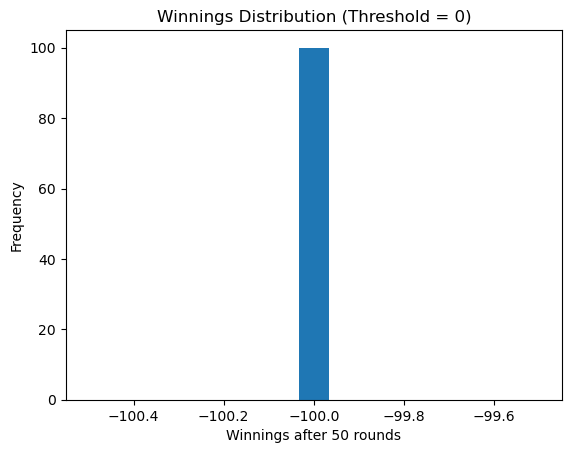

In [10]:
mean_total = sum(results) / len(results)
avg_per_round = mean_total / ROUNDS_PER_GAME

std_dev = math.sqrt(sum((x - mean_total)**2 for x in results) / len(results))

prob_win = sum(1 for x in results if x > 0) / len(results)
prob_loss = sum(1 for x in results if x < 0) / len(results)

print("Average winnings per round:", avg_per_round)
print("Standard deviation:", std_dev)
print("P(net win after 50 rounds):", prob_win)
print("P(net loss after 50 rounds):", prob_loss)

plt.figure()
plt.hist(results, bins=15)
plt.title(f"Winnings Distribution (Threshold = {THRESHOLD})")
plt.xlabel("Winnings after 50 rounds")
plt.ylabel("Frequency")
plt.show()

In [11]:
NUM_GAMES = 100
ROUNDS_PER_GAME = 50
STARTING_CHIPS = 100
THRESHOLD = -2

results = []

for _ in range(NUM_GAMES):
    game = Game([CountingPlayer("Counter", chips=STARTING_CHIPS, threshold=THRESHOLD)] +
                [CountingPlayer("Other1", threshold=1000),   # acts like dealer (never hits based on count)
                 CountingPlayer("Other2", threshold=1000),
                 CountingPlayer("Other3", threshold=1000)])
    
    for p in game.players[1:]:
        def dealer_style(self, deck, visible_cards):
            while self.hand.get_value() < 17:
                card = deck.draw_card()
                self.hand.add_card(card)
                visible_cards.append(card)
        p.play_turn = dealer_style.__get__(p)

    for _ in range(ROUNDS_PER_GAME):
        if game.players[0].chips <= 0:
            break
        game.play_round()

    winnings = game.players[0].chips - STARTING_CHIPS
    results.append(winnings)

Dealer: [2C, 5D, QS] (17)
Counter: [8H, 7S] (15)
Counter loses
Other1: [10S, QD] (20)
Other1 wins
Other2: [10C, KD] (20)
Other2 wins
Other3: [8D, 8H, 10C] (26)
Other3 loses
----------------------------------------
Dealer: [6D, 7H, 9D] (22)
Counter: [4C, 2D] (6)
Counter wins
Other1: [5H, JC, 7D] (22)
Other1 loses
Other2: [2C, JC, 2C, JH] (24)
Other2 loses
Other3: [AS, 7C] (18)
Other3 wins
----------------------------------------
Dealer: [AH, AC, QH, 7C] (19)
Counter: [3S, 3C] (6)
Counter loses
Other1: [7D, 8S, 6C] (21)
Other1 wins
Other2: [10C, 2S, 8H] (20)
Other2 wins
Other3: [8D, 7S, 4D] (19)
Other3 pushes
----------------------------------------
Dealer: [9D, JH] (19)
Counter: [4H, KH] (14)
Counter loses
Other1: [4S, JS, 2H, 4C] (20)
Other1 wins
Other2: [10D, KC] (20)
Other2 wins
Other3: [5D, 5C, KC] (20)
Other3 wins
----------------------------------------
Dealer: [9H, 6H, QH] (25)
Counter: [10D, KS, 5S] (25)
Counter loses
Other1: [JC, 9S] (19)
Other1 wins
Other2: [9C, QD] (19)
Other

Average winnings per round: -1.956
Standard deviation: 10.543244282477762
P(net win after 50 rounds): 0.0
P(net loss after 50 rounds): 1.0


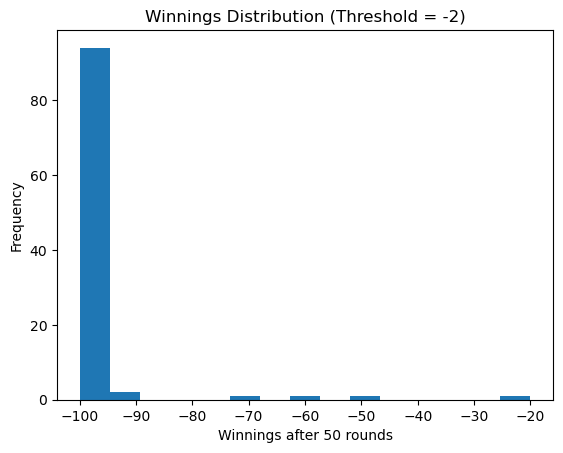

In [12]:
mean_total = sum(results) / len(results)
avg_per_round = mean_total / ROUNDS_PER_GAME

std_dev = math.sqrt(sum((x - mean_total)**2 for x in results) / len(results))

prob_win = sum(1 for x in results if x > 0) / len(results)
prob_loss = sum(1 for x in results if x < 0) / len(results)

print("Average winnings per round:", avg_per_round)
print("Standard deviation:", std_dev)
print("P(net win after 50 rounds):", prob_win)
print("P(net loss after 50 rounds):", prob_loss)

plt.figure()
plt.hist(results, bins=15)
plt.title(f"Winnings Distribution (Threshold = {THRESHOLD})")
plt.xlabel("Winnings after 50 rounds")
plt.ylabel("Frequency")
plt.show()

In [13]:
NUM_GAMES = 100
ROUNDS_PER_GAME = 50
STARTING_CHIPS = 100
THRESHOLD = -1

results = []

for _ in range(NUM_GAMES):
    game = Game([CountingPlayer("Counter", chips=STARTING_CHIPS, threshold=THRESHOLD)] +
                [CountingPlayer("Other1", threshold=1000),
                 CountingPlayer("Other2", threshold=1000),
                 CountingPlayer("Other3", threshold=1000)])
    
    for p in game.players[1:]:
        def dealer_style(self, deck, visible_cards):
            while self.hand.get_value() < 17:
                card = deck.draw_card()
                self.hand.add_card(card)
                visible_cards.append(card)
        p.play_turn = dealer_style.__get__(p)

    for _ in range(ROUNDS_PER_GAME):
        if game.players[0].chips <= 0:
            break
        game.play_round()

    winnings = game.players[0].chips - STARTING_CHIPS
    results.append(winnings)

Dealer: [9S, 4H, 6S] (19)
Counter: [AC, KS, QC, 10S] (31)
Counter loses
Other1: [4H, AC, 7S, 4S, AS] (17)
Other1 loses
Other2: [9D, 5C, 5H] (19)
Other2 pushes
Other3: [AC, JC] (21)
Other3 wins
----------------------------------------
Dealer: [AS, JH] (21)
Counter: [10C, 8C, 7H] (25)
Counter loses
Other1: [QS, AD] (21)
Other1 pushes
Other2: [8H, QC] (18)
Other2 loses
Other3: [JS, 7H] (17)
Other3 loses
----------------------------------------
Dealer: [KD, 10H] (20)
Counter: [7H, 6S] (13)
Counter loses
Other1: [5C, 9C, AH, 4C] (19)
Other1 loses
Other2: [JH, 7C] (17)
Other2 loses
Other3: [5C, QC, AS, 10D] (26)
Other3 loses
----------------------------------------
Dealer: [10H, KS] (20)
Counter: [AD, 3C, 6S, 6C, 7H] (23)
Counter loses
Other1: [KH, AH] (21)
Other1 wins
Other2: [9S, 6H, 2D] (17)
Other2 loses
Other3: [10D, 10S] (20)
Other3 pushes
----------------------------------------
Dealer: [2H, KH, 3D, 10D] (25)
Counter: [8D, JD] (18)
Counter wins
Other1: [6C, JC, 5D] (21)
Other1 wins
Oth

Average winnings per round: -1.974
Standard deviation: 8.562125904236634
P(net win after 50 rounds): 0.0
P(net loss after 50 rounds): 1.0


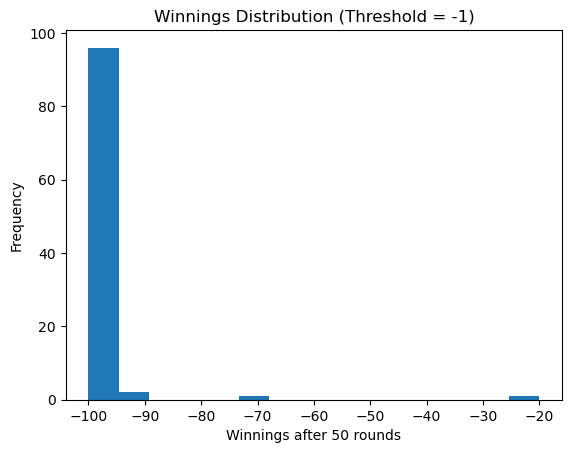

In [14]:
mean_total = sum(results) / len(results)
avg_per_round = mean_total / ROUNDS_PER_GAME

std_dev = math.sqrt(sum((x - mean_total)**2 for x in results) / len(results))

prob_win = sum(1 for x in results if x > 0) / len(results)
prob_loss = sum(1 for x in results if x < 0) / len(results)

print("Average winnings per round:", avg_per_round)
print("Standard deviation:", std_dev)
print("P(net win after 50 rounds):", prob_win)
print("P(net loss after 50 rounds):", prob_loss)

plt.figure()
plt.hist(results, bins=15)
plt.title(f"Winnings Distribution (Threshold = {THRESHOLD})")
plt.xlabel("Winnings after 50 rounds")
plt.ylabel("Frequency")
plt.show()

In [15]:
NUM_GAMES = 100
ROUNDS_PER_GAME = 50
STARTING_CHIPS = 100
THRESHOLD = 1

results = []

for _ in range(NUM_GAMES):
    game = Game([CountingPlayer("Counter", chips=STARTING_CHIPS, threshold=THRESHOLD)] +
                [CountingPlayer("Other1", threshold=1000),
                 CountingPlayer("Other2", threshold=1000),
                 CountingPlayer("Other3", threshold=1000)])
    
    for p in game.players[1:]:
        def dealer_style(self, deck, visible_cards):
            while self.hand.get_value() < 17:
                card = deck.draw_card()
                self.hand.add_card(card)
                visible_cards.append(card)
        p.play_turn = dealer_style.__get__(p)

    for _ in range(ROUNDS_PER_GAME):
        if game.players[0].chips <= 0:
            break
        game.play_round()

    winnings = game.players[0].chips - STARTING_CHIPS
    results.append(winnings)

Dealer: [4D, JC, 9D] (23)
Counter: [10H, QH, AS, 4H] (25)
Counter loses
Other1: [5C, 4S, 6S, 8S] (23)
Other1 loses
Other2: [QC, 5S, QH] (25)
Other2 loses
Other3: [JC, JD] (20)
Other3 wins
----------------------------------------
Dealer: [4D, QC, 4S] (18)
Counter: [5D, 4H] (9)
Counter loses
Other1: [2C, 10S, 8D] (20)
Other1 wins
Other2: [8H, 5H, 9D] (22)
Other2 loses
Other3: [6H, 5H, 5H, 10S] (26)
Other3 loses
----------------------------------------
Dealer: [KS, AC] (21)
Counter: [QH, 4S, KS] (24)
Counter loses
Other1: [4D, 3D, 9C, 9C] (25)
Other1 loses
Other2: [QS, AH] (21)
Other2 pushes
Other3: [6D, JD, 9H] (25)
Other3 loses
----------------------------------------
Dealer: [5H, KS, 6H] (21)
Counter: [2S, 7S] (9)
Counter loses
Other1: [9S, 2S, 9D] (20)
Other1 loses
Other2: [6H, 2D, JH] (18)
Other2 loses
Other3: [2C, 5C, 6H, 6C] (19)
Other3 loses
----------------------------------------
Dealer: [JS, KC] (20)
Counter: [2S, 3C, 7S, 3S, 2D] (17)
Counter loses
Other1: [JH, 5D, 5D] (20)
Oth

Average winnings per round: -2.0
Standard deviation: 0.0
P(net win after 50 rounds): 0.0
P(net loss after 50 rounds): 1.0


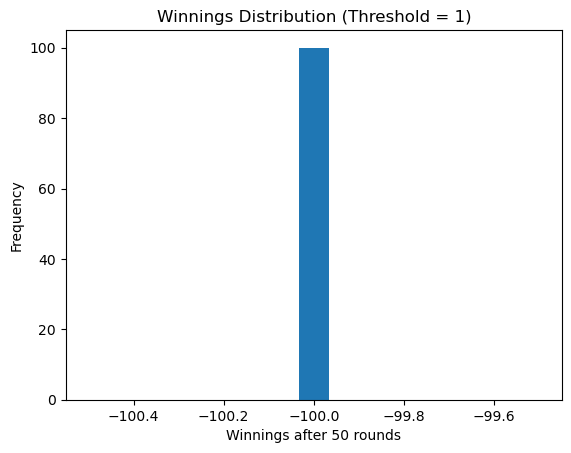

In [16]:
mean_total = sum(results) / len(results)
avg_per_round = mean_total / ROUNDS_PER_GAME

std_dev = math.sqrt(sum((x - mean_total)**2 for x in results) / len(results))

prob_win = sum(1 for x in results if x > 0) / len(results)
prob_loss = sum(1 for x in results if x < 0) / len(results)

print("Average winnings per round:", avg_per_round)
print("Standard deviation:", std_dev)
print("P(net win after 50 rounds):", prob_win)
print("P(net loss after 50 rounds):", prob_loss)

plt.figure()
plt.hist(results, bins=15)
plt.title(f"Winnings Distribution (Threshold = {THRESHOLD})")
plt.xlabel("Winnings after 50 rounds")
plt.ylabel("Frequency")
plt.show()

In [17]:
NUM_GAMES = 100
ROUNDS_PER_GAME = 50
STARTING_CHIPS = 100
THRESHOLD = 2

results = []

for _ in range(NUM_GAMES):
    game = Game([CountingPlayer("Counter", chips=STARTING_CHIPS, threshold=THRESHOLD)] +
                [CountingPlayer("Other1", threshold=1000),
                 CountingPlayer("Other2", threshold=1000),
                 CountingPlayer("Other3", threshold=1000)])
    
    for p in game.players[1:]:
        def dealer_style(self, deck, visible_cards):
            while self.hand.get_value() < 17:
                card = deck.draw_card()
                self.hand.add_card(card)
                visible_cards.append(card)
        p.play_turn = dealer_style.__get__(p)

    for _ in range(ROUNDS_PER_GAME):
        if game.players[0].chips <= 0:
            break
        game.play_round()

    winnings = game.players[0].chips - STARTING_CHIPS
    results.append(winnings)

Dealer: [5D, 10C, 5S] (20)
Counter: [KD, 10D, JH] (30)
Counter loses
Other1: [7D, 7C, 5S] (19)
Other1 loses
Other2: [5C, 3D, 8D, 10S] (26)
Other2 loses
Other3: [JS, KH] (20)
Other3 pushes
----------------------------------------
Dealer: [AD, KD] (21)
Counter: [5H, 2H, 6S, 8H, 10D] (31)
Counter loses
Other1: [10S, 2H, 8C] (20)
Other1 loses
Other2: [KC, 4H, AC, 6S] (21)
Other2 pushes
Other3: [6C, AS] (17)
Other3 loses
----------------------------------------
Dealer: [10H, 4C, AH, 5H] (20)
Counter: [6S, 8H] (14)
Counter loses
Other1: [2H, 7D, 7S, 6C] (22)
Other1 loses
Other2: [4S, 9D, 2D, JC] (25)
Other2 loses
Other3: [6C, 5H, 10H] (21)
Other3 wins
----------------------------------------
Dealer: [4S, 5S, 7H, 9H] (25)
Counter: [AC, 3D] (14)
Counter wins
Other1: [5D, 9S, 3H] (17)
Other1 wins
Other2: [8S, 4D, 6D] (18)
Other2 wins
Other3: [9H, KD] (19)
Other3 wins
----------------------------------------
Dealer: [2S, 6S, 5H, KC] (23)
Counter: [2S, 6H] (8)
Counter wins
Other1: [10C, KC] (20)


Average winnings per round: -2.0
Standard deviation: 0.0
P(net win after 50 rounds): 0.0
P(net loss after 50 rounds): 1.0


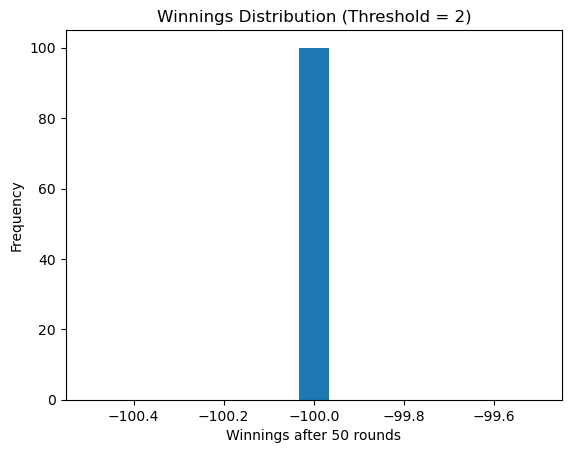

In [18]:
mean_total = sum(results) / len(results)
avg_per_round = mean_total / ROUNDS_PER_GAME

std_dev = math.sqrt(sum((x - mean_total)**2 for x in results) / len(results))

prob_win = sum(1 for x in results if x > 0) / len(results)
prob_loss = sum(1 for x in results if x < 0) / len(results)

print("Average winnings per round:", avg_per_round)
print("Standard deviation:", std_dev)
print("P(net win after 50 rounds):", prob_win)
print("P(net loss after 50 rounds):", prob_loss)

plt.figure()
plt.hist(results, bins=15)
plt.title(f"Winnings Distribution (Threshold = {THRESHOLD})")
plt.xlabel("Winnings after 50 rounds")
plt.ylabel("Frequency")
plt.show()

In [19]:
class IbraCountingPlayer(Player):
    def __init__(self, name, chips=100):
        super().__init__(name, chips)
        self.count = 0

    def update_count(self, card):
        if card.rank in ['2','3','4','5','6']:
            self.count += 1
        elif card.rank in ['10','J','Q','K','A']:
            self.count -= 1

    def place_bet(self):

        if self.count > 2:
            self.bet = 20
        elif self.count > 0:
            self.bet = 15
        else:
            self.bet = 5

    def play_turn(self, deck, visible_cards):

        self.count = 0
        for c in visible_cards:
            self.update_count(c)

        while True:
            if self.hand.is_bust():
                break

            value = self.hand.get_value()


            if self.count < -1:
                hit = value < 18
            elif self.count > 1:
                hit = value < 15
            else:
                hit = value < 17

            if hit:
                card = deck.draw_card()
                self.hand.add_card(card)
                visible_cards.append(card)
                self.update_count(card)
            else:
                break

In [20]:
def run_simulation(player_class, label):
    results = []

    for _ in range(100):
        p_main = player_class("Test", chips=100)

        others = []
        for i in range(3):
            p = CountingPlayer(f"Other{i}", threshold=1000)
            def dealer_style(self, deck, visible_cards):
                while self.hand.get_value() < 17:
                    card = deck.draw_card()
                    self.hand.add_card(card)
                    visible_cards.append(card)
            p.play_turn = dealer_style.__get__(p)
            others.append(p)

        game = Game([p_main] + others)

        for _ in range(50):
            if p_main.chips <= 0:
                break
            p_main.place_bet()
            game.play_round()

        results.append(p_main.chips - 100)

    avg = sum(results)/len(results)/50
    return avg, results

In [21]:
old_avg, old_results = run_simulation(lambda n, chips: CountingPlayer(n, chips, threshold=-2), "Old")
new_avg, new_results = run_simulation(IbraCountingPlayer, "New")

print("Old Strategy Avg per round:", old_avg)
print("New Strategy Avg per round:", new_avg)


Dealer: [QD, 5S, KC] (25)
Test: [2D, 6D] (8)
Test wins
Other0: [2C, AC, 7H] (20)
Other0 wins
Other1: [4C, 4H, 5C, 3D, QS] (26)
Other1 loses
Other2: [2H, QC, JD] (22)
Other2 loses
----------------------------------------
Dealer: [2C, 9C, 10C] (21)
Test: [10H, 4D] (14)
Test loses
Other0: [5C, KH, 4D] (19)
Other0 loses
Other1: [JC, QD] (20)
Other1 loses
Other2: [7S, 7S, KH] (24)
Other2 loses
----------------------------------------
Dealer: [JS, 4H, AH, 10D] (25)
Test: [6D, 3S] (9)
Test wins
Other0: [9S, 5D, 2D, 6H] (22)
Other0 loses
Other1: [AD, JS] (21)
Other1 wins
Other2: [5C, 10D, 10C] (25)
Other2 loses
----------------------------------------
Dealer: [4S, 3D, 5H, 8C] (20)
Test: [7D, QD] (17)
Test loses
Other0: [5D, 7C, 6C] (18)
Other0 loses
Other1: [2C, 3C, AH, QS, 9D] (25)
Other1 loses
Other2: [5D, 6D, 5H, 8S] (24)
Other2 loses
----------------------------------------
Dealer: [QH, 9D] (19)
Test: [5C, JD, 4S, 8C] (27)
Test loses
Other0: [AH, 9H] (20)
Other0 wins
Other1: [QC, QS] (20)


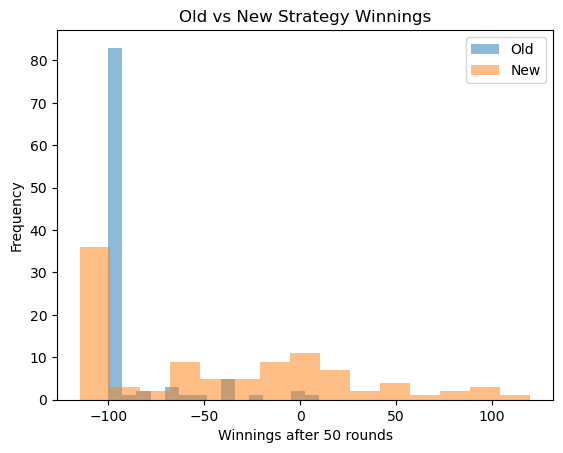

In [22]:
plt.figure()
plt.hist(old_results, bins=15, alpha=0.5, label="Old")
plt.hist(new_results, bins=15, alpha=0.5, label="New")
plt.legend()
plt.title("Old vs New Strategy Winnings")
plt.xlabel("Winnings after 50 rounds")
plt.ylabel("Frequency")
plt.show()